# MountainCarContinuous Random Baseline

## 实验目标

这个 notebook 不训练任何策略，只统计 `MountainCarContinuous-v0` 在随机连续动作下的表现。目标是先建立一个清晰基线：在必须精细控制连续油门、通过蓄能把小车送上右侧山顶的任务里，随机动作通常既难以形成有效节奏，也会浪费大量能量。后续 `SAC` 的训练结果会以这份 baseline 作为参照。

## 方法说明

这里的方法就是纯随机动作采样：每一步从动作空间中随机取一个连续推力，不维护价值函数，也不更新策略。

In [1]:
from pathlib import Path

import gymnasium as gym
import imageio.v2 as imageio
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

In [2]:
ENV_ID = "MountainCarContinuous-v0"
NUM_EPISODES = 600
MAX_STEPS = 999
ROLLOUT_EPISODES = 3
ROLLOUT_FPS = 30
SUCCESS_THRESHOLD_RETURN = 90
SEED = 42

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

env = gym.make(ENV_ID)

In [3]:
episode_rewards = []
final_positions = []
max_positions = []
successes = []
mean_abs_actions = []

for episode in tqdm(range(NUM_EPISODES), desc="Random episodes"):
    obs, info = env.reset(seed=SEED + episode)
    total_reward = 0.0
    best_position = float(obs[0])
    actions = []

    for step in range(MAX_STEPS):
        action = env.action_space.sample()
        obs, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        best_position = max(best_position, float(obs[0]))
        actions.append(abs(float(action[0])))
        if terminated or truncated:
            break

    episode_rewards.append(total_reward)
    final_positions.append(float(obs[0]))
    max_positions.append(best_position)
    successes.append(int(total_reward >= SUCCESS_THRESHOLD_RETURN))
    mean_abs_actions.append(float(np.mean(actions)))

env.close()

Random episodes:   0%|          | 0/600 [00:00<?, ?it/s]

In [4]:
summary = pd.DataFrame({"reward": episode_rewards, "final_position": final_positions, "max_position": max_positions, "success": successes, "mean_abs_action": mean_abs_actions})
metrics = pd.DataFrame({"metric": ["average_reward", "success_rate", "average_final_position", "average_max_position", "average_mean_abs_action"], "value": [float(np.mean(episode_rewards)), float(np.mean(successes)), float(np.mean(final_positions)), float(np.mean(max_positions)), float(np.mean(mean_abs_actions))]})
metrics

,metric,value
0,average_reward,-32.936210
1,success_rate,0.000000
2,average_final_position,-0.508952
3,average_max_position,-0.149377
4,average_mean_abs_action,0.499794


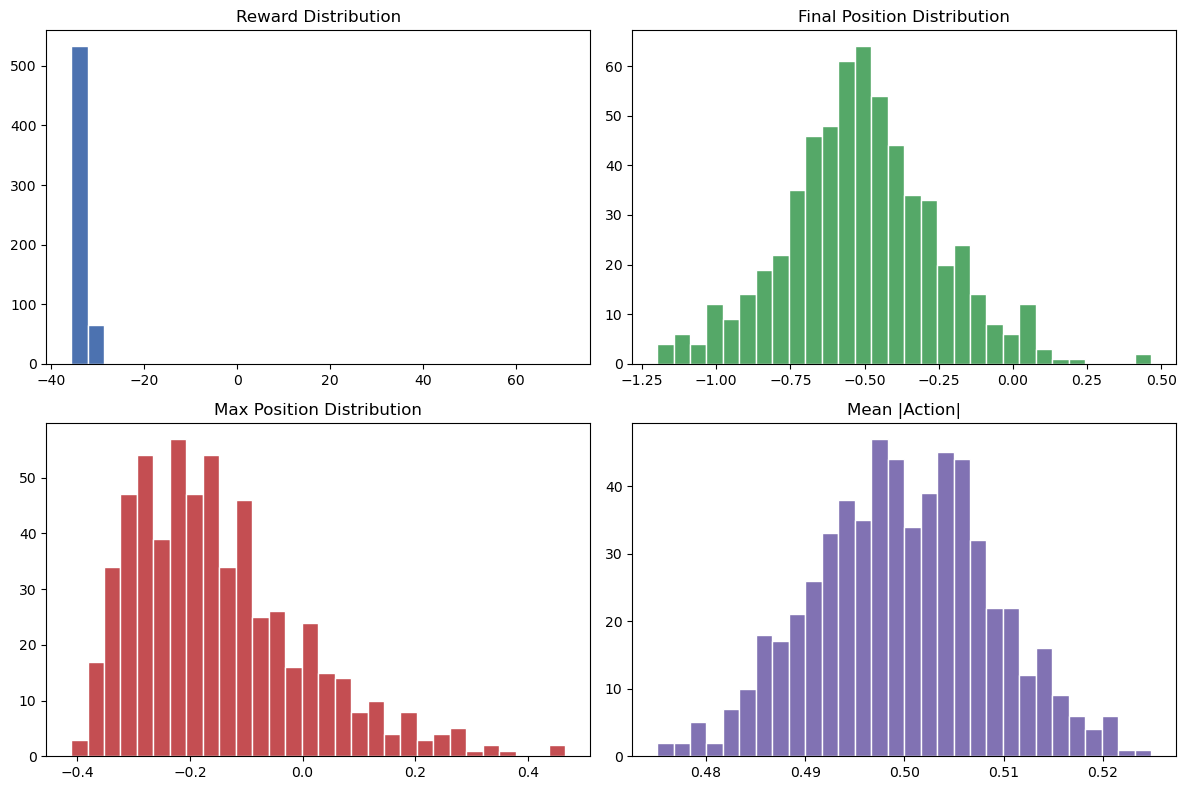

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0, 0].hist(episode_rewards, bins=30, color="#4c72b0", edgecolor="white")
axes[0, 0].set_title("Reward Distribution")
axes[0, 1].hist(final_positions, bins=30, color="#55a868", edgecolor="white")
axes[0, 1].set_title("Final Position Distribution")
axes[1, 0].hist(max_positions, bins=30, color="#c44e52", edgecolor="white")
axes[1, 0].set_title("Max Position Distribution")
axes[1, 1].hist(mean_abs_actions, bins=30, color="#8172b3", edgecolor="white")
axes[1, 1].set_title("Mean |Action|")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "random_baseline_overview.png", dpi=150, bbox_inches="tight")
plt.show()

In [6]:
rollout_summaries = []
for rollout_idx in range(ROLLOUT_EPISODES):
    rollout_env = gym.make(ENV_ID, render_mode="rgb_array")
    obs, info = rollout_env.reset(seed=SEED + 1000 + rollout_idx)
    frames = []
    total_reward = 0.0
    best_position = float(obs[0])
    actions = []
    for step in range(MAX_STEPS):
        frame = rollout_env.render()
        if frame is not None:
            frames.append(frame)
        action = rollout_env.action_space.sample()
        obs, reward, terminated, truncated, info = rollout_env.step(action)
        total_reward += reward
        best_position = max(best_position, float(obs[0]))
        actions.append(abs(float(action[0])))
        if terminated or truncated:
            break
    final_frame = rollout_env.render()
    if final_frame is not None:
        frames.extend([final_frame] * 20)
    rollout_summaries.append({"rollout_index": rollout_idx + 1, "seed": SEED + 1000 + rollout_idx, "total_reward": float(total_reward), "final_position": float(obs[0]), "max_position": float(best_position), "mean_abs_action": float(np.mean(actions)), "success": int(total_reward >= SUCCESS_THRESHOLD_RETURN)})
    if frames:
        imageio.mimsave(RESULTS_DIR / f"random_baseline_rollout_{rollout_idx + 1}.gif", frames, fps=ROLLOUT_FPS)
    rollout_env.close()

pd.DataFrame(rollout_summaries)

,rollout_index,seed,total_reward,final_position,max_position,mean_abs_action,success
0,1,1042,-34.753825,-0.450962,-0.250087,0.515265,0
1,2,1043,-34.357479,-0.522183,-0.207340,0.507556,0
2,3,1044,-34.095244,-0.570790,-0.354291,0.504451,0


In [7]:
summary.to_csv(RESULTS_DIR / "random_baseline_episode_summary.csv", index=False)
metrics.to_csv(RESULTS_DIR / "random_baseline_metrics.csv", index=False)
pd.DataFrame(rollout_summaries).to_csv(RESULTS_DIR / "random_baseline_rollout_summary.csv", index=False)
print(metrics.to_string(index=False))

                 metric      value
         average_reward -32.936210
           success_rate   0.000000
 average_final_position  -0.508952
   average_max_position  -0.149377
average_mean_abs_action   0.499794
